# HW4: Metro Violations Agent — Full Experiment

**All-in-one notebook** for GPU server:
1. Setup & data generation
2. Baseline evaluation (Qwen 1.5B without training)
3. GRPO training with progress tracking
4. GRPO evaluation
5. Comparison & analysis plots

In [ ]:
!unzip hw4.zip && mv hw4/* . && rm -rf hw4

Archive:  hw4.zip
   creating: hw4/
   creating: hw4/.git/
 extracting: hw4/.git/COMMIT_EDITMSG  
  inflating: hw4/.git/config         
  inflating: hw4/.git/description    
 extracting: hw4/.git/HEAD           
   creating: hw4/.git/hooks/
  inflating: hw4/.git/hooks/applypatch-msg.sample  
  inflating: hw4/.git/hooks/commit-msg.sample  
  inflating: hw4/.git/hooks/fsmonitor-watchman.sample  
  inflating: hw4/.git/hooks/post-update.sample  
  inflating: hw4/.git/hooks/pre-applypatch.sample  
  inflating: hw4/.git/hooks/pre-commit.sample  
  inflating: hw4/.git/hooks/pre-merge-commit.sample  
  inflating: hw4/.git/hooks/pre-push.sample  
  inflating: hw4/.git/hooks/pre-rebase.sample  
  inflating: hw4/.git/hooks/pre-receive.sample  
  inflating: hw4/.git/hooks/prepare-commit-msg.sample  
  inflating: hw4/.git/hooks/push-to-checkout.sample  
  inflating: hw4/.git/hooks/update.sample  
  inflating: hw4/.git/index          
   creating: hw4/.git/info/
  inflating: hw4/.git/info/exclude   

In [1]:
!pip install -q torch transformers trl peft accelerate wandb matplotlib pandas tqdm vllm

In [2]:
!pip install bitsandbytes -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 35.2 MB/s eta 0:00:00


In [3]:
import os
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["VLLM_USE_V1"] = "0"

import json
import time
from vllm import LLM, SamplingParams

In [2]:
import os, sys, json, time, random
import torch
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
from tqdm.auto import tqdm
from collections import defaultdict

sys.path.insert(0, '.')

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


## 1. Generate Data

## 2. Baseline Evaluation (Qwen 1.5B, no fine-tuning)

In [ ]:
from base.data import Data
from env.metro_env import MetroViolationsEnv
from verifier.trajectory_verifier import MetroTrajectoryVerifier
from agent.baseline_agent import BaselineAgent

def load_episodes(path, limit=None):
    eps = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                eps.append(Data.from_json(line.strip()))
                if limit and len(eps) >= limit:
                    break
    return eps

agent = BaselineAgent(model_name='Qwen/Qwen2.5-1.5B-Instruct', device='auto')
env = MetroViolationsEnv()
verifier = MetroTrajectoryVerifier()

Loading model: Qwen/Qwen2.5-1.5B-Instruct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded on cuda:0


In [4]:
os.makedirs('logs', exist_ok=True)
baseline_results = {}

for bucket in range(1, 6):
    data_path = f'data/eval_d{bucket}.jsonl'
    if not os.path.exists(data_path):
        print(f'Skipping {data_path} (not found)')
        continue

    episodes = load_episodes(data_path)
    print(f'\n{"="*60}')
    print(f'Baseline eval_d{bucket}: {len(episodes)} episodes')
    print('=' * 60)

    all_metrics = []
    all_trajectories = []
    t0 = time.time()

    for i, ep in enumerate(tqdm(episodes, desc=f'eval_d{bucket}')):
        result = agent.run_episode(env, ep, verbose=False)
        metrics = verifier.verify_trajectory(env, ep, result['actions'])
        all_metrics.append({
            'question_id': ep.question_id,
            'difficulty': ep.difficulty,
            'task_type': ep.task_type,
            **metrics,
        })
        all_trajectories.append({
            **result,
            'metrics': {k: v for k, v in metrics.items() if k != 'info_trace'},
        })

    dt = time.time() - t0
    n = len(all_metrics)
    summary = {
        'model': 'baseline',
        'bucket': f'eval_d{bucket}',
        'total_episodes': n,
        'success_rate': sum(m['success'] for m in all_metrics) / n,
        'mean_reward': sum(m['total_reward'] for m in all_metrics) / n,
        'mean_steps': sum(m['steps'] for m in all_metrics) / n,
        'mean_tool_calls': sum(m['tool_calls'] for m in all_metrics) / n,
        'mean_policy_violations': sum(m['policy_violations'] for m in all_metrics) / n,
        'mean_invalid_actions': sum(m['invalid_actions'] for m in all_metrics) / n,
        'time_seconds': dt,
        'per_episode': all_metrics,
    }
    baseline_results[f'eval_d{bucket}'] = summary

    # Save
    with open(f'logs/metrics_baseline_eval_d{bucket}.json', 'w') as f:
        json.dump(summary, f, indent=2, ensure_ascii=False)
    with open(f'logs/trajectories_baseline_eval_d{bucket}.jsonl', 'w') as f:
        for t in all_trajectories:
            f.write(json.dumps(t, ensure_ascii=False) + '\n')

    print(f'  Success: {summary["success_rate"]:.1%} | Reward: {summary["mean_reward"]:.3f} | '
          f'Steps: {summary["mean_steps"]:.1f} | Tools: {summary["mean_tool_calls"]:.1f} | '
          f'Violations: {summary["mean_policy_violations"]:.2f} | Time: {dt:.0f}s')

NameError: name 'load_episodes' is not defined

In [ ]:
# Архивация логов
import shutil
shutil.make_archive('logs_archive', 'zip', '.', 'logs')
print('Создан logs_archive.zip')

# Скачивание (для Google Colab / Kaggle)
try:
    from google.colab import files
    files.download('logs_archive.zip')
except ImportError:
    try:
        from IPython.display import FileLink
        display(FileLink('logs_archive.zip'))
    except:
        print('Файл logs_archive.zip готов к скачиванию вручную')


Создан logs_archive.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Baseline summary table
print(f'{"Bucket":<12} {"Success":>10} {"Reward":>10} {"Steps":>8} {"Tools":>8} {"Violations":>12}')
print('-' * 62)
for b, s in sorted(baseline_results.items()):
    print(f'{b:<12} {s["success_rate"]:>9.1%} {s["mean_reward"]:>10.3f} '
          f'{s["mean_steps"]:>8.1f} {s["mean_tool_calls"]:>8.1f} {s["mean_policy_violations"]:>12.2f}')

Bucket          Success     Reward    Steps    Tools   Violations
--------------------------------------------------------------
eval_d1           0.0%     -1.115      5.4      0.5         0.00
eval_d2           0.0%     -1.161      7.3      0.6         0.00
eval_d3           9.0%     -1.037     10.0      1.3         0.04
eval_d4          23.0%     -0.774     10.2      1.5         0.01
eval_d5           3.0%     -1.206     12.2      1.8         0.01


## 3. GRPO Training

In [ ]:
# Free baseline model memory
del agent
torch.cuda.empty_cache()

NameError: name 'agent' is not defined

In [2]:
#from training.grpo_train import GRPOConfig, GRPOTrainer
'''
config = GRPOConfig(
    model_name='Qwen/Qwen2.5-1.5B-Instruct',
    output_dir='checkpoints/grpo',
    num_epochs=2,
    batch_size=1,
    num_generations=2,
    learning_rate=5e-6,
    use_lora=True,
    lora_r=16,
    lora_alpha=32,
    log_dir='logs/training',
    log_every=5,
    eval_every=50,
    save_every=100,
    use_wandb=False,  # set True if wandb configured
    eval_limit=10,
    max_steps_per_episode=15,
)
'''

from training.grpo_train_vllm import GRPOVLLMConfig, GRPOVLLMTrainer

config = GRPOVLLMConfig(
    model_name='Qwen/Qwen2.5-0.5B-Instruct',
    num_epochs=3,
    rollout_batch_size=30,      # 30 эпизодов за 1 vLLM сессию
    num_generations=2,
    train_subset_per_difficulty=30,  # 30 эпиз × 10 уровней = 300 всего
    max_steps_per_episode=8,
    curriculum_schedule={1: 4, 2: 7, 3: 10},
)

trainer = GRPOVLLMTrainer(config)
logs = trainer.train()


#trainer = GRPOTrainer(config)
#trainer.setup_model()
#trainer.load_data()


2026-03-13 12:54:09,666 - GRPOvLLM - INFO - Training data: 300 episodes (subsampled from 2350)
2026-03-13 12:54:09,668 - GRPOvLLM - INFO - Eval eval_d1: 10 episodes
2026-03-13 12:54:09,670 - GRPOvLLM - INFO - Eval eval_d2: 10 episodes
2026-03-13 12:54:09,672 - GRPOvLLM - INFO - Eval eval_d3: 10 episodes
2026-03-13 12:54:09,673 - GRPOvLLM - INFO - Eval eval_d4: 10 episodes
2026-03-13 12:54:09,675 - GRPOvLLM - INFO - Eval eval_d5: 10 episodes


GRPO Training:   0%|          | 0/21 [00:00<?, ?batch/s]

2026-03-13 12:54:09,685 - GRPOvLLM - INFO - 
Epoch 1/3 (d1-d4, 120 episodes)
2026-03-13 12:54:09,685 - GRPOvLLM - INFO - 
--- Rollout batch 1/21 (30 episodes) ---


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

WARNING 03-13 13:39:34 [vllm.py:781] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 03-13 13:39:34 [vllm.py:792] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
2026-03-13 13:40:04,717 - GRPOvLLM - INFO -   60 rollouts initialized, starting parallel generation...
2026-03-13 13:40:10,686 - GRPOvLLM - INFO -   Step 1/8: generated 60 actions, 0 still active
2026-03-13 13:40:15,501 - GRPOvLLM - INFO - Phase 1 done: 60 rollouts, GPU free: 41.0 GB
2026-03-13 13:40:15,565 - GRPOvLLM - INFO - Phase 2: Loading HF model for training...
2026-03-13 13:40:19,225 - GRPOvLLM - INFO - Loaded existing LoRA weights
2026-03-13 13:40:19,239 - GRPOvLLM - INFO -   QID fd102c24: rewards=[-1.02, -1.02], mean=-1.02, adv=['0.00', '0.00']
2026-03-13 13:40:19,239 - GRPOvLLM - INFO -     Rollout 0: adv=0.00, steps=1, succ=False
2026-03-

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


WARNING 03-13 13:40:23 [vllm.py:781] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 03-13 13:40:23 [vllm.py:792] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
2026-03-13 13:40:54,154 - GRPOvLLM - INFO -   60 rollouts initialized, starting parallel generation...
2026-03-13 13:41:09,482 - GRPOvLLM - INFO -   Step 1/8: generated 60 actions, 0 still active
2026-03-13 13:41:14,325 - GRPOvLLM - INFO - Phase 1 done: 60 rollouts, GPU free: 41.0 GB
2026-03-13 13:41:14,393 - GRPOvLLM - INFO - Phase 2: Loading HF model for training...
2026-03-13 13:41:17,995 - GRPOvLLM - INFO - Loaded existing LoRA weights
2026-03-13 13:41:18,009 - GRPOvLLM - INFO -   QID 601c54f3: rewards=[-1.02, -1.02], mean=-1.02, adv=['0.00', '0.00']
2026-03-13 13:41:18,009 - GRPOvLLM - INFO -     Rollout 0: adv=0.00, steps=1, succ=False
2026-03-

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


WARNING 03-13 13:41:23 [vllm.py:781] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 03-13 13:41:23 [vllm.py:792] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
2026-03-13 13:41:53,573 - GRPOvLLM - INFO -   50 rollouts initialized, starting parallel generation...
2026-03-13 13:42:08,313 - GRPOvLLM - INFO -   Step 1/8: generated 50 actions, 0 still active
2026-03-13 13:42:12,820 - GRPOvLLM - INFO - Phase 1 done: 50 rollouts, GPU free: 41.0 GB
2026-03-13 13:42:12,878 - GRPOvLLM - INFO -   eval_d1: success=20.0%, reward=-0.620
2026-03-13 13:42:12,879 - GRPOvLLM - INFO -   eval_d2: success=0.0%, reward=-1.020
2026-03-13 13:42:12,880 - GRPOvLLM - INFO -   eval_d3: success=0.0%, reward=-1.020
2026-03-13 13:42:12,881 - GRPOvLLM - INFO -   eval_d4: success=0.0%, reward=-1.020
2026-03-13 13:42:12,881 - GRPOvLLM - INF

## 4. Training Curves

Читаем логи из: logs/training/train_vllm_20260313_125409.jsonl


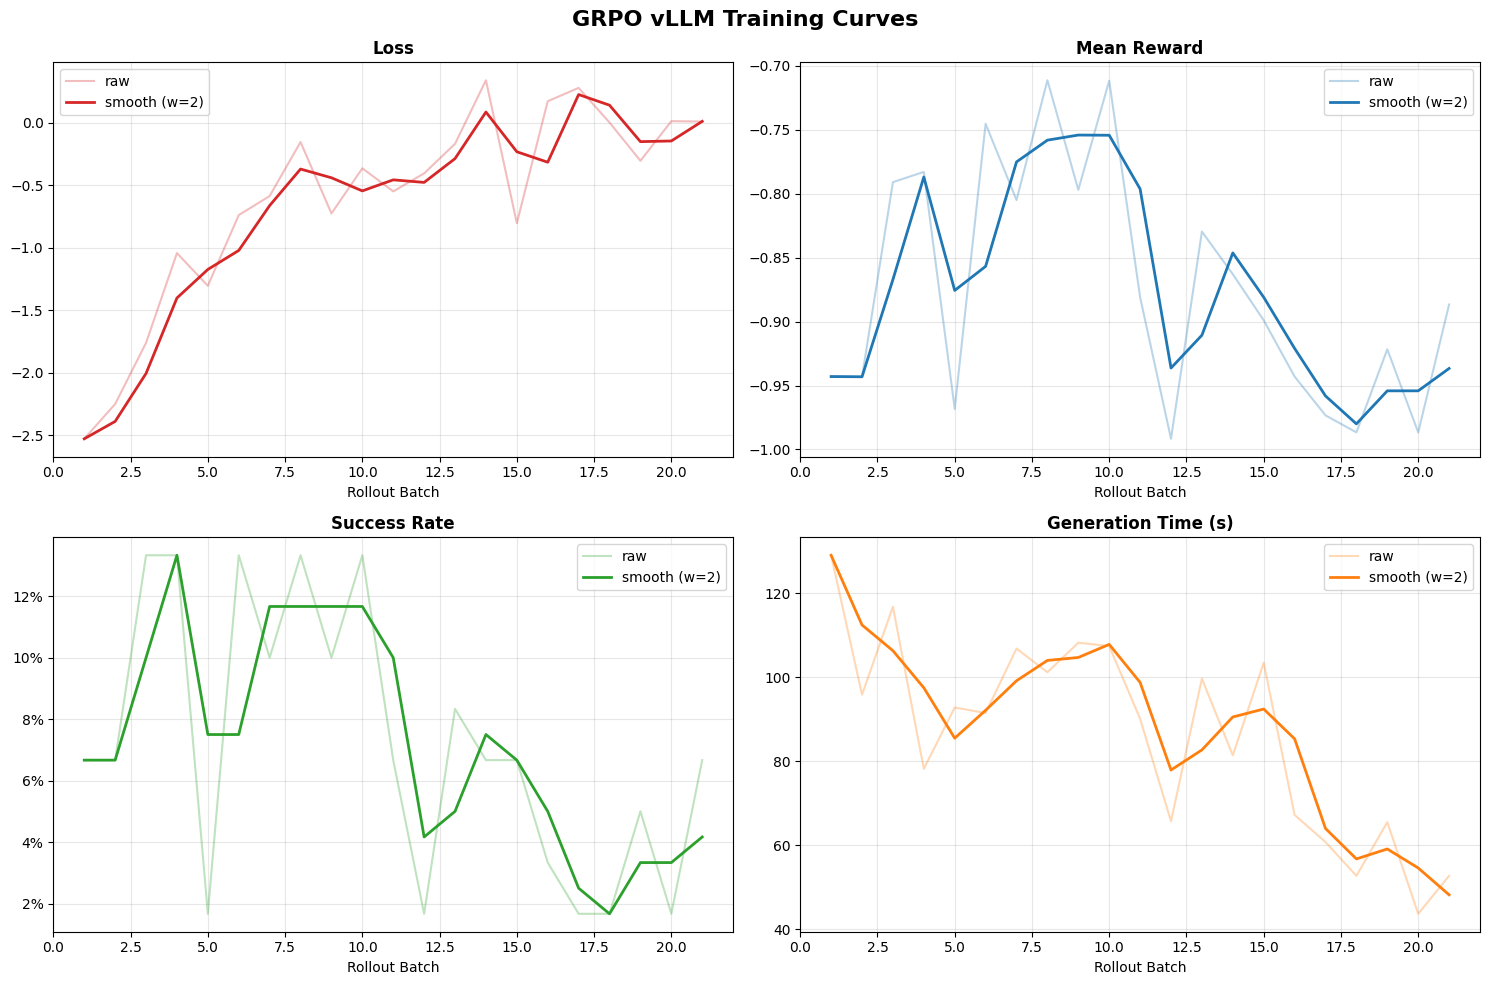

In [3]:
import os
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt

# Ищем последний файл с логами обучения
log_files = glob.glob('logs/training/train_vllm_*.jsonl')
if not log_files:
    print("Не найдены логи обучения!")
else:
    latest_log = max(log_files, key=os.path.getmtime)
    print(f"Читаем логи из: {latest_log}")

    train_logs = []
    with open(latest_log, 'r') as f:
        for line in f:
            try:
                train_logs.append(json.loads(line.strip()))
            except:
                pass

    df = pd.DataFrame(train_logs)

    if not df.empty:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('GRPO vLLM Training Curves', fontsize=16, fontweight='bold')

        plots = [
            ('loss', 'Loss', 'tab:red'),
            ('mean_reward', 'Mean Reward', 'tab:blue'),
            ('success_rate', 'Success Rate', 'tab:green'),
            ('time_gen', 'Generation Time (s)', 'tab:orange'),
        ]

        df['step'] = df['rollout_batch']
        w = max(1, len(df) // 10)

        for ax, (key, title, color) in zip(axes.flatten(), plots):
            if key in df.columns:
                sm = df[key].rolling(window=w, min_periods=1).mean()
                ax.plot(df['step'], df[key], color=color, alpha=0.3, label='raw')
                ax.plot(df['step'], sm, color=color, linewidth=2, label=f'smooth (w={w})')
                ax.set_title(title, fontweight='bold')
                ax.set_xlabel('Rollout Batch')
                ax.grid(alpha=0.3)
                ax.legend()

                if key == 'success_rate':
                    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

        plt.tight_layout()
        os.makedirs('logs/plots', exist_ok=True)
        plt.savefig('logs/plots/vllm_training_curves.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('Файл логов пуст.')


## 5. GRPO Evaluation

In [1]:
import os
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["VLLM_USE_V1"] = "0"
os.environ["VLLM_RPC_TIMEOUT"] = "100" # Даём больше времени на инициализацию

import json
import time
from tqdm.auto import tqdm
from vllm import LLM, SamplingParams
from vllm.lora.request import LoRARequest

from env.metro_env import MetroViolationsEnv
from verifier.trajectory_verifier import MetroTrajectoryVerifier
from base.data import Data
from agent.baseline_agent import SYSTEM_PROMPT

def load_episodes(path):
    if not os.path.exists(path):
        return []
    with open(path, 'r', encoding='utf-8') as f:
        return [Data.from_json(line.strip()) for line in f if line.strip()]

print("Запуск финального тестирования...")

# Загружаем vLLM максимально защищённо
llm = LLM(
    model="Qwen/Qwen2.5-0.5B-Instruct",
    enable_lora=True,
    max_lora_rank=16,
    gpu_memory_utilization=0.6,
    max_model_len=2048,
    trust_remote_code=True,
    enforce_eager=True,
    enable_chunked_prefill=False, # Отключаем префилл, который иногда крашит A100 на старте
)
lora_request = LoRARequest("grpo_model", 1, "checkpoints/grpo/_latest_lora")

env = MetroViolationsEnv()
verifier = MetroTrajectoryVerifier()
sampling_params = SamplingParams(temperature=0.0, max_tokens=256, stop=["---ACTION---"])

results = {}
os.makedirs('logs', exist_ok=True)

# Прогоняем по всем 5 датасетам
for bucket in range(1, 6):
    data_path = f'data/eval_d{bucket}.jsonl'
    episodes = load_episodes(data_path)
    if not episodes: continue

    print(f'\n{"="*60}\nGRPO eval_d{bucket}: {len(episodes)} episodes')

    all_metrics, all_trajectories = [], []
    t0 = time.time()

    for ep in tqdm(episodes, desc=f'eval_d{bucket}'):
        obs = env.reset(ep)
        messages = [{"role": "system", "content": SYSTEM_PROMPT}]
        messages.append({"role": "user", "content": obs})

        actions_taken = []
        done = False

        for step in range(8):
            prompt = llm.get_tokenizer().apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )
            # Генерируем с помощью vLLM
            outputs = llm.generate([prompt], sampling_params, lora_request=lora_request, use_tqdm=False)
            action_text = outputs[0].outputs[0].text.strip()

            # Сохраняем действие
            messages.append({"role": "assistant", "content": action_text})
            actions_taken.append(action_text)

            # Делаем шаг в среде, используя сгенерированный текст
            obs, reward, done, info = env.step(action_text)
            messages.append({"role": "user", "content": obs})
            if done: break

        # Оцениваем всю траекторию целиком
        metrics = verifier.verify_trajectory(env, ep, actions_taken)
        all_metrics.append({'question_id': ep.question_id, 'difficulty': ep.difficulty,
                            'task_type': ep.task_type, **metrics})
        all_trajectories.append({'messages': messages, 'actions': actions_taken,
                                 'metrics': {k:v for k,v in metrics.items() if k != 'info_trace'}})

    dt = time.time() - t0
    n = len(all_metrics)
    summary = {
        'model': 'grpo_vllm', 'bucket': f'eval_d{bucket}', 'total_episodes': n,
        'success_rate': sum(m['success'] for m in all_metrics) / n,
        'mean_reward': sum(m['total_reward'] for m in all_metrics) / n,
        'mean_steps': sum(m['steps'] for m in all_metrics) / n,
        'mean_tool_calls': sum(m['tool_calls'] for m in all_metrics) / n,
        'mean_policy_violations': sum(m['policy_violations'] for m in all_metrics) / n,
        'time_seconds': dt,
    }

    with open(f'logs/metrics_grpo_eval_d{bucket}.json', 'w') as f:
        json.dump(summary, f, indent=2, ensure_ascii=False)
    with open(f'logs/trajectories_grpo_eval_d{bucket}.jsonl', 'w') as f:
        for t in all_trajectories: f.write(json.dumps(t, ensure_ascii=False) + '\n')

    print(f'  Success: {summary["success_rate"]:.1%} | Reward: {summary["mean_reward"]:.3f} | '
          f'Steps: {summary["mean_steps"]:.1f} | Time: {dt:.0f}s')

print("\nОценка завершена! Данные сохранены в папке logs/")


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

  Success: 3.0% | Reward: -0.902 | Steps: 2.1 | Time: 333s

GRPO eval_d4: 100 episodes


eval_d4:   0%|          | 0/100 [00:00<?, ?it/s]

  Success: 2.0% | Reward: -0.980 | Steps: 1.0 | Time: 104s

GRPO eval_d5: 100 episodes


eval_d5:   0%|          | 0/100 [00:00<?, ?it/s]

  Success: 0.0% | Reward: -1.020 | Steps: 1.0 | Time: 72s

Оценка завершена! Данные сохранены в папке logs/


In [2]:
import os
import shutil
from google.colab import files

print("Создаем временные папки для сортировки...")
os.makedirs("export_eval", exist_ok=True)

# 1. Отделяем логи финального эвала от логов обучения
# Всё, что лежит прямо в logs/ (но не в logs/training) — это финальный эвал и графики
for item in os.listdir("logs"):
    path = os.path.join("logs", item)
    if os.path.isfile(path):  # Копируем только файлы (метрики, траектории)
        shutil.copy2(path, "export_eval")
if os.path.exists("logs/plots"):
    shutil.copytree("logs/plots", "export_eval/plots", dirs_exist_ok=True)

print("Запаковываем архивы...")

# 1. Архив с весами (LoRA)
if os.path.exists("checkpoints/grpo/_latest_lora"):
    shutil.make_archive("grpo_model_weights", "zip", "checkpoints/grpo/_latest_lora")
else:
    print("ВНИМАНИЕ: Папка _latest_lora не найдена!")

# 2. Архив с логами обучения (процесс GRPO)
if os.path.exists("logs/training"):
    shutil.make_archive("grpo_training_logs", "zip", "logs/training")
else:
    print("ВНИМАНИЕ: Папка logs/training не найдена!")

# 3. Архив с результатами финального эвала (метрики и диалоги)
shutil.make_archive("grpo_eval_results", "zip", "export_eval")

print("Архивы созданы! Начинаю скачивание...")

# Скачиваем на твой компьютер
try:
    if os.path.exists("grpo_model_weights.zip"):
        files.download("grpo_model_weights.zip")
    if os.path.exists("grpo_training_logs.zip"):
        files.download("grpo_training_logs.zip")
    if os.path.exists("grpo_eval_results.zip"):
        files.download("grpo_eval_results.zip")
except Exception as e:
    print(f"Ошибка при автоматическом скачивании: {e}")
    print("Файлы *.zip лежат в корневой папке на сервере. Скачай их руками слева в меню файлов!")


Создаем временные папки для сортировки...
Запаковываем архивы...
Архивы созданы! Начинаю скачивание...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,bucket,success_rate,mean_reward,mean_steps,mean_tool_calls,mean_policy_violations,time_seconds
0,eval_d1,0.17,-0.6800,1.00,0.0,0.0,185.2101
1,eval_d2,0.00,-1.0200,1.00,0.0,0.0,212.0632
2,eval_d3,0.03,-0.9022,2.11,0.0,0.0,333.1788
3,eval_d4,0.02,-0.9800,1.00,0.0,0.0,104.3468
4,eval_d5,0.00,-1.0200,1.00,0.0,0.0,71.7706


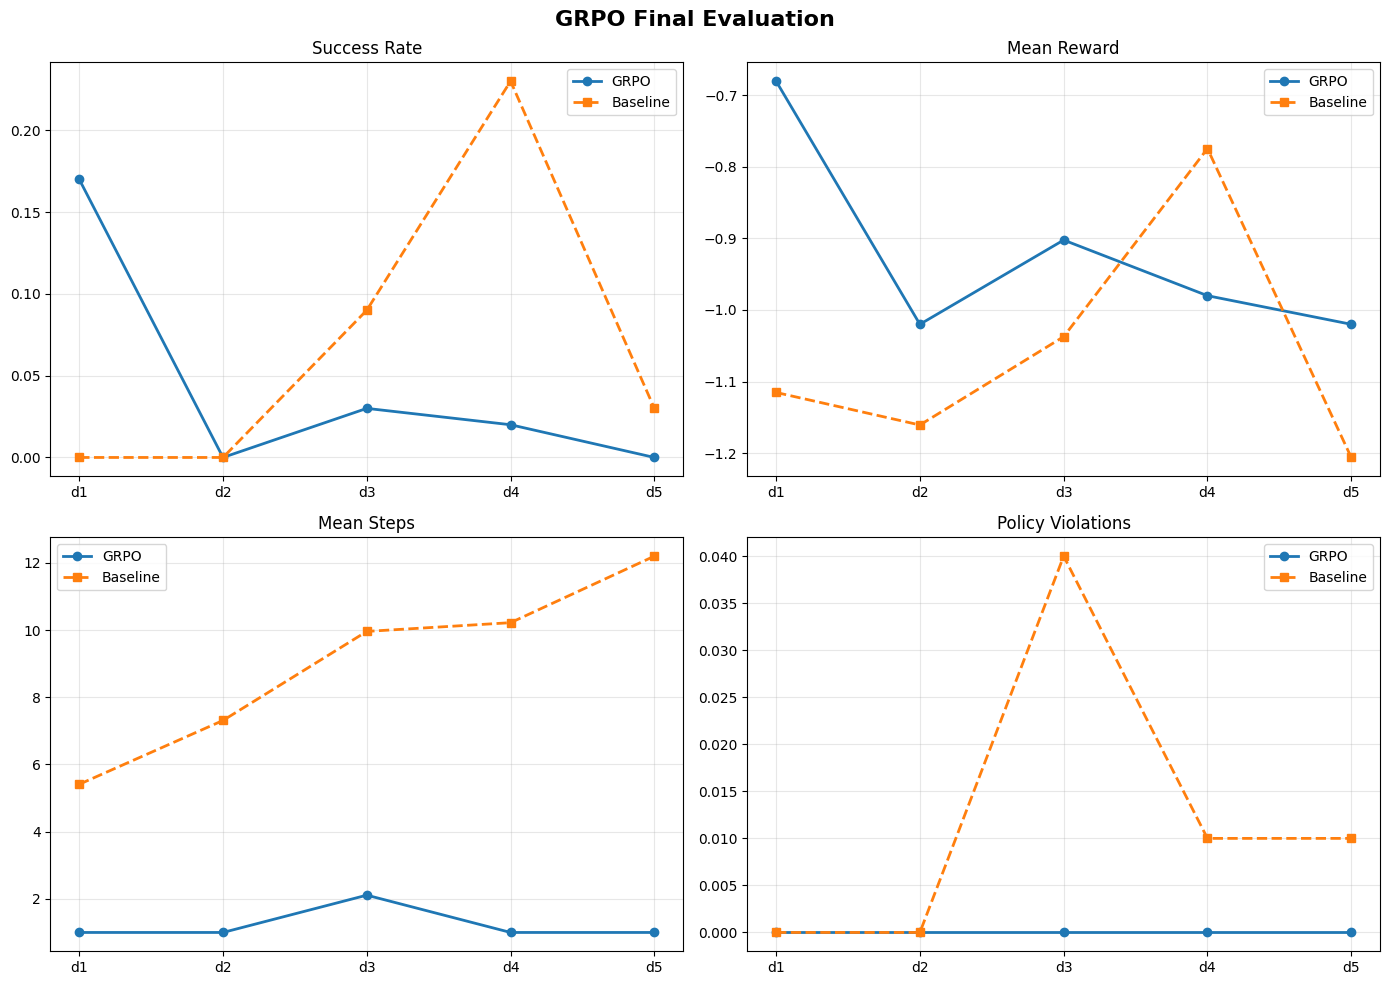

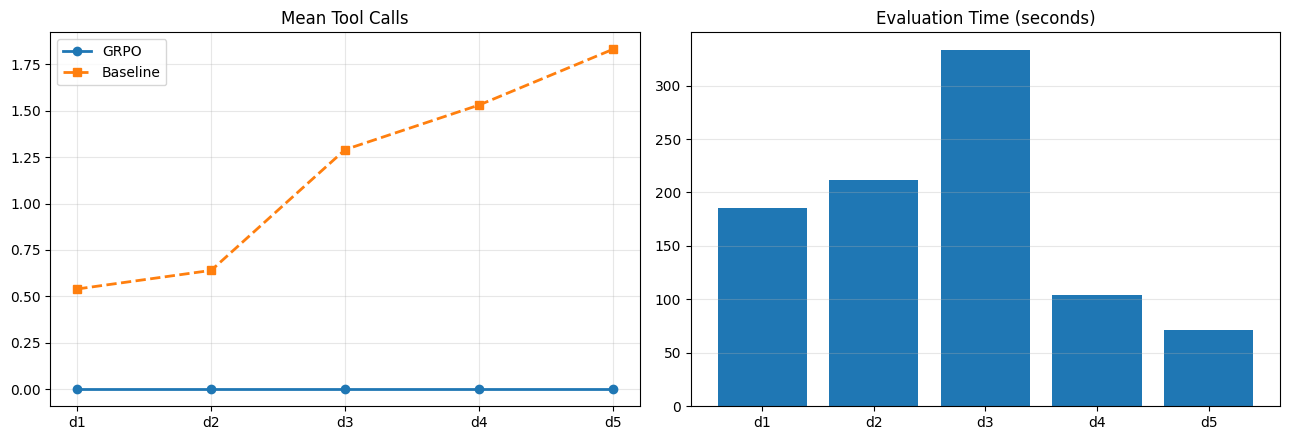

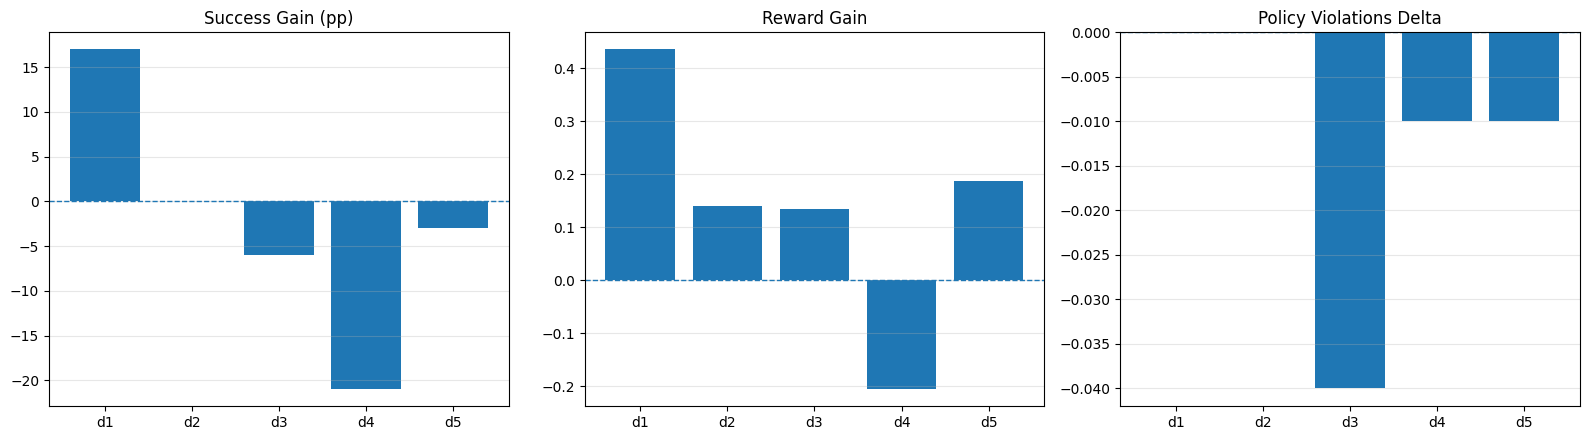


GRPO summary by bucket:
 bucket  success_rate  mean_reward  mean_steps  mean_tool_calls  mean_policy_violations  time_seconds
eval_d1          0.17      -0.6800        1.00              0.0                     0.0      185.2101
eval_d2          0.00      -1.0200        1.00              0.0                     0.0      212.0632
eval_d3          0.03      -0.9022        2.11              0.0                     0.0      333.1788
eval_d4          0.02      -0.9800        1.00              0.0                     0.0      104.3468
eval_d5          0.00      -1.0200        1.00              0.0                     0.0       71.7706

Графики сохранены в logs/plots/


In [3]:
# Графики после финального eval GRPO
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("logs/plots", exist_ok=True)

# Загружаем метрики GRPO
metric_files = sorted(glob.glob("logs/metrics_grpo_eval_d*.json"))
if not metric_files:
    raise FileNotFoundError("Не найдены файлы logs/metrics_grpo_eval_d*.json")

rows = []
for path in metric_files:
    with open(path, "r", encoding="utf-8") as f:
        rows.append(json.load(f))

df = pd.DataFrame(rows)

# Номер бакета из eval_dX
df["bucket_id"] = (
    df["bucket"]
    .astype(str)
    .str.extract(r"eval_d(\d+)")
    .astype(int)
)
df = df.sort_values("bucket_id").reset_index(drop=True)

# Если есть baseline-метрики, подтянем для сравнения
baseline_files = sorted(glob.glob("logs/metrics_baseline_eval_d*.json"))
baseline_df = None
if baseline_files:
    base_rows = []
    for path in baseline_files:
        with open(path, "r", encoding="utf-8") as f:
            base_rows.append(json.load(f))
    baseline_df = pd.DataFrame(base_rows)
    baseline_df["bucket_id"] = (
        baseline_df["bucket"]
        .astype(str)
        .str.extract(r"eval_d(\d+)")
        .astype(int)
    )
    baseline_df = baseline_df.sort_values("bucket_id").reset_index(drop=True)

display(df[[
    "bucket", "success_rate", "mean_reward",
    "mean_steps", "mean_tool_calls", "mean_policy_violations", "time_seconds"
]].round(4))

x = df["bucket_id"].tolist()
xticks = [f"d{i}" for i in x]

# ---------- График 1: основные метрики ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("GRPO Final Evaluation", fontsize=16, fontweight="bold")

metrics_to_plot = [
    ("success_rate", "Success Rate"),
    ("mean_reward", "Mean Reward"),
    ("mean_steps", "Mean Steps"),
    ("mean_policy_violations", "Policy Violations"),
]

for ax, (col, title) in zip(axes.flatten(), metrics_to_plot):
    ax.plot(x, df[col], marker="o", linewidth=2, label="GRPO")
    if baseline_df is not None and col in baseline_df.columns:
        ax.plot(
            baseline_df["bucket_id"], baseline_df[col],
            marker="s", linestyle="--", linewidth=2, label="Baseline"
        )
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(xticks)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig("logs/plots/grpo_eval_main_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------- График 2: tool calls + runtime ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(x, df["mean_tool_calls"], marker="o", linewidth=2)
if baseline_df is not None and "mean_tool_calls" in baseline_df.columns:
    axes[0].plot(
        baseline_df["bucket_id"], baseline_df["mean_tool_calls"],
        marker="s", linestyle="--", linewidth=2
    )
axes[0].set_title("Mean Tool Calls")
axes[0].set_xticks(x)
axes[0].set_xticklabels(xticks)
axes[0].grid(alpha=0.3)
axes[0].legend(["GRPO"] + (["Baseline"] if baseline_df is not None else []))

axes[1].bar(x, df["time_seconds"])
axes[1].set_title("Evaluation Time (seconds)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(xticks)
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("logs/plots/grpo_eval_runtime_tools.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------- График 3: improvement vs baseline ----------
if baseline_df is not None:
    merged = df.merge(
        baseline_df,
        on="bucket_id",
        suffixes=("_grpo", "_baseline")
    )
    merged["success_gain_pp"] = 100 * (merged["success_rate_grpo"] - merged["success_rate_baseline"])
    merged["reward_gain"] = merged["mean_reward_grpo"] - merged["mean_reward_baseline"]
    merged["violations_delta"] = merged["mean_policy_violations_grpo"] - merged["mean_policy_violations_baseline"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    axes[0].bar(merged["bucket_id"], merged["success_gain_pp"])
    axes[0].axhline(0, linestyle="--", linewidth=1)
    axes[0].set_title("Success Gain (pp)")
    axes[0].set_xticks(merged["bucket_id"])
    axes[0].set_xticklabels([f"d{i}" for i in merged["bucket_id"]])
    axes[0].grid(alpha=0.3, axis="y")

    axes[1].bar(merged["bucket_id"], merged["reward_gain"])
    axes[1].axhline(0, linestyle="--", linewidth=1)
    axes[1].set_title("Reward Gain")
    axes[1].set_xticks(merged["bucket_id"])
    axes[1].set_xticklabels([f"d{i}" for i in merged["bucket_id"]])
    axes[1].grid(alpha=0.3, axis="y")

    axes[2].bar(merged["bucket_id"], merged["violations_delta"])
    axes[2].axhline(0, linestyle="--", linewidth=1)
    axes[2].set_title("Policy Violations Delta")
    axes[2].set_xticks(merged["bucket_id"])
    axes[2].set_xticklabels([f"d{i}" for i in merged["bucket_id"]])
    axes[2].grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig("logs/plots/grpo_vs_baseline_deltas.png", dpi=150, bbox_inches="tight")
    plt.show()

# ---------- Краткая сводка ----------
print("\nGRPO summary by bucket:")
print(df[[
    "bucket", "success_rate", "mean_reward",
    "mean_steps", "mean_tool_calls", "mean_policy_violations", "time_seconds"
]].round(4).to_string(index=False))

print("\nГрафики сохранены в logs/plots/")

,bucket,question_id,difficulty,task_type,success,total_reward,steps,tool_calls,policy_violations,invalid_actions,num_actions,final_answer,actions,raw,bucket_id
0,eval_d1,None,None,None,0,-1.02,1,0,0,0,1,None,[FINAL_ANSWER 5],"{'messages': [{'role': 'system', 'content': 'Y...",1
1,eval_d1,None,None,None,0,-1.02,1,0,0,0,1,None,[FINAL_ANSWER 17],"{'messages': [{'role': 'system', 'content': 'Y...",1
2,eval_d1,None,None,None,1,0.98,1,0,0,0,1,None,[FINAL_ANSWER 5],"{'messages': [{'role': 'system', 'content': 'Y...",1


Всего траекторий: 500

Сводка по eval bucket:


,bucket_id,success_rate,mean_steps,mean_actions,mean_reward,mean_tool_calls,mean_policy_violations,mean_invalid_actions
0,1,0.17,1.00,1.00,-0.6800,0.0,0.0,0.0
1,2,0.00,1.00,1.00,-1.0200,0.0,0.0,0.0
2,3,0.03,2.11,2.11,-0.9022,0.0,0.0,0.0
3,4,0.02,1.00,1.00,-0.9800,0.0,0.0,0.0
4,5,0.00,1.00,1.00,-1.0200,0.0,0.0,0.0


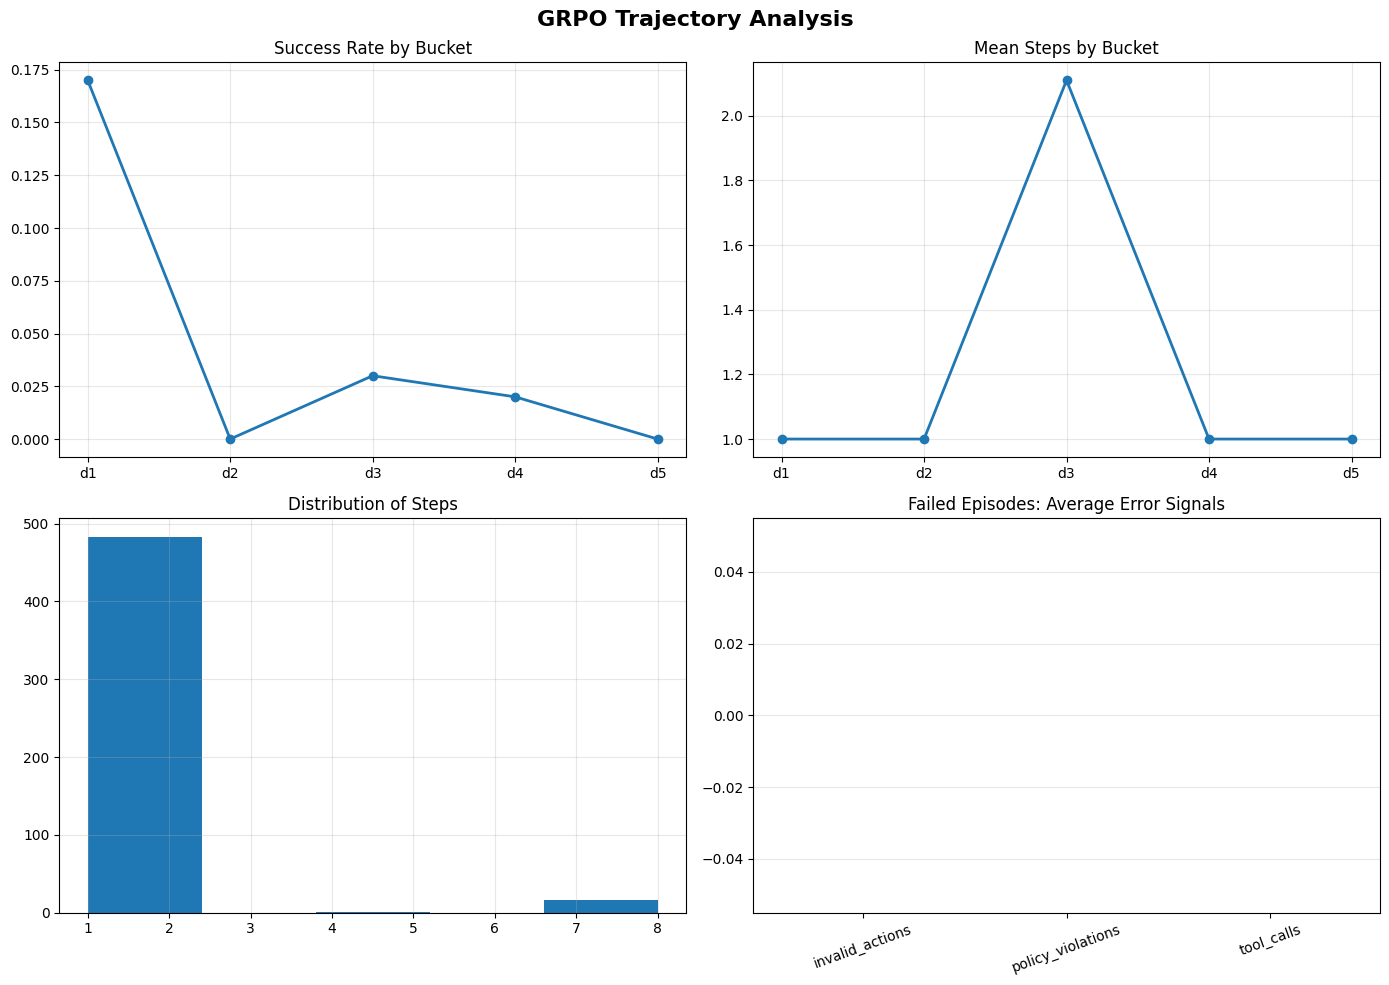


Лучшие успешные примеры:


,bucket,question_id,task_type,difficulty,success,total_reward,steps,tool_calls,policy_violations,invalid_actions
2,eval_d1,None,None,None,1,0.98,1,0,0,0
24,eval_d1,None,None,None,1,0.98,1,0,0,0
25,eval_d1,None,None,None,1,0.98,1,0,0,0
26,eval_d1,None,None,None,1,0.98,1,0,0,0
39,eval_d1,None,None,None,1,0.98,1,0,0,0



Худшие неуспешные примеры:


,bucket,question_id,task_type,difficulty,success,total_reward,steps,tool_calls,policy_violations,invalid_actions
236,eval_d3,None,None,None,0,-1.16,8,0,0,0
281,eval_d3,None,None,None,0,-1.16,8,0,0,0
283,eval_d3,None,None,None,0,-1.16,8,0,0,0
274,eval_d3,None,None,None,0,-1.14,7,0,0,0
278,eval_d3,None,None,None,0,-1.14,7,0,0,0
282,eval_d3,None,None,None,0,-1.14,7,0,0,0
255,eval_d3,None,None,None,0,-1.10,5,0,0,0
0,eval_d1,None,None,None,0,-1.02,1,0,0,0
1,eval_d1,None,None,None,0,-1.02,1,0,0,0
3,eval_d1,None,None,None,0,-1.02,1,0,0,0



Несколько характерных failed cases:

bucket=eval_d1 | qid=None | task_type=None | difficulty=None
success=0 | reward=-1.02 | steps=1 | tool_calls=0 | violations=0 | invalid=0
actions:
  1. FINAL_ANSWER 5
final_answer:
None
bucket=eval_d1 | qid=None | task_type=None | difficulty=None
success=0 | reward=-1.02 | steps=1 | tool_calls=0 | violations=0 | invalid=0
actions:
  1. FINAL_ANSWER 17
final_answer:
None
bucket=eval_d1 | qid=None | task_type=None | difficulty=None
success=0 | reward=-1.02 | steps=1 | tool_calls=0 | violations=0 | invalid=0
actions:
  1. FINAL_ANSWER 5
final_answer:
None

Готово. Графики сохранены в logs/plots/


In [4]:
# Анализ траекторий после финального eval GRPO:
# - распределение success / failure
# - длина траекторий
# - tool calls / invalid actions / policy violations
# - типичные провальные примеры
# - по task_type и difficulty, если поля есть

import os
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("logs/plots", exist_ok=True)

traj_files = sorted(glob.glob("logs/trajectories_grpo_eval_d*.jsonl"))
if not traj_files:
    raise FileNotFoundError("Не найдены файлы logs/trajectories_grpo_eval_d*.jsonl")

rows = []
for path in traj_files:
    bucket = os.path.basename(path).replace("trajectories_grpo_", "").replace(".jsonl", "")
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            x = json.loads(line)

            metrics = x.get("metrics", {}) or {}
            episode = x.get("episode", {}) or {}
            actions = x.get("actions", []) or []

            rows.append({
                "bucket": bucket,
                "question_id": (
                    x.get("question_id")
                    or episode.get("question_id")
                    or x.get("id")
                ),
                "difficulty": (
                    metrics.get("difficulty")
                    if metrics.get("difficulty") is not None
                    else episode.get("difficulty")
                ),
                "task_type": (
                    metrics.get("task_type")
                    if metrics.get("task_type") is not None
                    else episode.get("task_type")
                ),
                "success": int(metrics.get("success", 0)),
                "total_reward": metrics.get("total_reward"),
                "steps": metrics.get("steps", len(actions)),
                "tool_calls": metrics.get("tool_calls"),
                "policy_violations": metrics.get("policy_violations"),
                "invalid_actions": metrics.get("invalid_actions"),
                "num_actions": len(actions),
                "final_answer": x.get("final_answer"),
                "actions": actions,
                "raw": x,
            })

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError("Файлы траекторий есть, но они пустые")

df["bucket_id"] = (
    df["bucket"].astype(str).str.extract(r"eval_d(\d+)").astype(int)
)
df = df.sort_values(["bucket_id"]).reset_index(drop=True)

display(df.head(3))
print(f"Всего траекторий: {len(df)}")

# ---------- Сводка по бакетам ----------
agg = {
    "success": "mean",
    "steps": "mean",
    "num_actions": "mean",
}
for col in ["total_reward", "tool_calls", "policy_violations", "invalid_actions"]:
    if col in df.columns:
        agg[col] = "mean"

bucket_summary = (
    df.groupby("bucket_id", as_index=False)
      .agg(agg)
      .rename(columns={
          "success": "success_rate",
          "steps": "mean_steps",
          "num_actions": "mean_actions",
          "total_reward": "mean_reward",
          "tool_calls": "mean_tool_calls",
          "policy_violations": "mean_policy_violations",
          "invalid_actions": "mean_invalid_actions",
      })
)

print("\nСводка по eval bucket:")
display(bucket_summary.round(4))

# ---------- Графики ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("GRPO Trajectory Analysis", fontsize=16, fontweight="bold")

# 1. Success rate
axes[0, 0].plot(bucket_summary["bucket_id"], bucket_summary["success_rate"], marker="o", linewidth=2)
axes[0, 0].set_title("Success Rate by Bucket")
axes[0, 0].set_xticks(bucket_summary["bucket_id"])
axes[0, 0].set_xticklabels([f"d{i}" for i in bucket_summary["bucket_id"]])
axes[0, 0].grid(alpha=0.3)

# 2. Mean steps
axes[0, 1].plot(bucket_summary["bucket_id"], bucket_summary["mean_steps"], marker="o", linewidth=2)
axes[0, 1].set_title("Mean Steps by Bucket")
axes[0, 1].set_xticks(bucket_summary["bucket_id"])
axes[0, 1].set_xticklabels([f"d{i}" for i in bucket_summary["bucket_id"]])
axes[0, 1].grid(alpha=0.3)

# 3. Histogram of steps
axes[1, 0].hist(df["steps"].dropna(), bins=min(20, max(5, df["steps"].nunique())))
axes[1, 0].set_title("Distribution of Steps")
axes[1, 0].grid(alpha=0.3)

# 4. Failure reasons proxy
failure_cols = [c for c in ["invalid_actions", "policy_violations", "tool_calls"] if c in df.columns]
fail_df = df[df["success"] == 0]
if not fail_df.empty and failure_cols:
    fail_means = fail_df[failure_cols].mean().sort_values(ascending=False)
    axes[1, 1].bar(fail_means.index, fail_means.values)
    axes[1, 1].set_title("Failed Episodes: Average Error Signals")
    axes[1, 1].tick_params(axis='x', rotation=20)
    axes[1, 1].grid(alpha=0.3, axis="y")
else:
    axes[1, 1].text(0.5, 0.5, "Недостаточно данных", ha="center", va="center")
    axes[1, 1].set_title("Failed Episodes: Average Error Signals")
    axes[1, 1].axis("off")

plt.tight_layout()
plt.savefig("logs/plots/grpo_trajectory_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------- Анализ по task_type ----------
if "task_type" in df.columns and df["task_type"].notna().any():
    task_summary = (
        df.groupby("task_type", dropna=False)
          .agg(
              n=("success", "size"),
              success_rate=("success", "mean"),
              mean_steps=("steps", "mean"),
          )
          .sort_values(["success_rate", "n"], ascending=[False, False])
          .reset_index()
    )
    print("\nПо типам задач:")
    display(task_summary.round(4))

    plt.figure(figsize=(10, 4))
    plt.bar(task_summary["task_type"].astype(str), task_summary["success_rate"])
    plt.title("Success Rate by Task Type")
    plt.xticks(rotation=30, ha="right")
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig("logs/plots/grpo_task_type_success.png", dpi=150, bbox_inches="tight")
    plt.show()

# ---------- Анализ по difficulty ----------
if "difficulty" in df.columns and df["difficulty"].notna().any():
    diff_summary = (
        df.groupby("difficulty", dropna=False)
          .agg(
              n=("success", "size"),
              success_rate=("success", "mean"),
              mean_steps=("steps", "mean"),
          )
          .sort_index()
          .reset_index()
    )
    print("\nПо difficulty:")
    display(diff_summary.round(4))

    plt.figure(figsize=(8, 4))
    plt.plot(diff_summary["difficulty"], diff_summary["success_rate"], marker="o")
    plt.title("Success Rate by Difficulty")
    plt.xlabel("Difficulty")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("logs/plots/grpo_difficulty_success.png", dpi=150, bbox_inches="tight")
    plt.show()

# ---------- Примеры лучших и худших ----------
sort_col = "total_reward" if "total_reward" in df.columns and df["total_reward"].notna().any() else None

print("\nЛучшие успешные примеры:")
best = df[df["success"] == 1].copy()
if not best.empty:
    if sort_col:
        best = best.sort_values([sort_col, "steps"], ascending=[False, True])
    else:
        best = best.sort_values(["steps"], ascending=[True])
    cols = [c for c in ["bucket", "question_id", "task_type", "difficulty", "success", "total_reward", "steps", "tool_calls", "policy_violations", "invalid_actions"] if c in best.columns]
    display(best[cols].head(5))
else:
    print("Успешных примеров нет")

print("\nХудшие неуспешные примеры:")
worst = df[df["success"] == 0].copy()
if not worst.empty:
    if sort_col:
        worst = worst.sort_values([sort_col, "policy_violations", "invalid_actions"], ascending=[True, False, False])
    else:
        extra_cols = [c for c in ["policy_violations", "invalid_actions", "steps"] if c in worst.columns]
        worst = worst.sort_values(extra_cols, ascending=[False] * len(extra_cols))
    cols = [c for c in ["bucket", "question_id", "task_type", "difficulty", "success", "total_reward", "steps", "tool_calls", "policy_violations", "invalid_actions"] if c in worst.columns]
    display(worst[cols].head(10))
else:
    print("Неуспешных примеров нет")

# ---------- Печать нескольких фейлов целиком ----------
print("\nНесколько характерных failed cases:\n")
sample_fails = df[df["success"] == 0].head(3)

for i, row in sample_fails.iterrows():
    print("=" * 100)
    print(f"bucket={row.get('bucket')} | qid={row.get('question_id')} | task_type={row.get('task_type')} | difficulty={row.get('difficulty')}")
    print(f"success={row.get('success')} | reward={row.get('total_reward')} | steps={row.get('steps')} | tool_calls={row.get('tool_calls')} | violations={row.get('policy_violations')} | invalid={row.get('invalid_actions')}")
    print("actions:")
    for j, act in enumerate(row.get("actions", [])[:10], 1):
        print(f"  {j}. {act}")
    if len(row.get("actions", [])) > 10:
        print("  ...")
    print("final_answer:")
    print(row.get("final_answer"))

print("\nГотово. Графики сохранены в logs/plots/")